Images Python Notebook
---
This notebook has the objective of setting the start of the proyect by the creation of the database that is going to be used in the machine learning algoritm training.\\

We will create images of dimension: 512 x 512 using the library PyCF ( https://www2.ccs.tsukuba.ac.jp/Astro/Members/ayw/code/pyFC/quickstart.html)\\

We will create this images from fractal cubes simulations with the library. This simulations will follow the Log Normal Distribution with a 
-   $\vec{X} = 1$
-   $\sigma = \sqrt{5}$ 
-   $\beta = \frac{-5}{3}$

What we refer to fractal cubes are randomly generated scalar fields in a $\R^3$ Field, $\rho (x_1, x_2, x_3)$ which comes from a PDF, and a fractal correlation in space, this two-point fractal distribution is given by the power law spectrum in Fourier Space. An characterized by the slope of the power law ($\beta$), finally the now most important feature are located on the Nyquist limit ($k_{max}$) and a lower cutoff wavenumber ($k_{min}$)

The cutoff wavenumber values will be: 2, 4, 8, 16, 32, 64 

We will create 1000 images per wavenumber so we can stablish a new synthetic dataset to train a convolutionla neural network arround the labels of the $k_{min}$ values.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pyFC
import matplotlib.pyplot as plt
import h5py
import os
import gc
import psutil
from datetime import datetime
import configparser
from typing import List, Optional, Tuple, Dict, Any
import logging

# Import the DatasetGen class from external module
from dataset_generator import DatasetGen

In [8]:
ni = 512
nj = 512
nk = 1  

mean = 1
sigma = np.sqrt(5.)
beta = -2

#Lets generate a cube of 512x512x1
fc = pyFC.LogNormalFractalCube(ni=ni, nj=nj, nk=nk,
                                 kmin=2,
                                 mean=mean,
                                 sigma=sigma,
                                 beta=beta)

fc.gen_cube(verbose=False)

print('fc.shape:', getattr(fc,'shape', None))
fcs = pyFC.FCSlicer()
s1 = fcs.slice(fc, 0) 
print('finite count:', np.isfinite(s1).sum(), 'total', s1.size)
print('min, max:', np.nanmin(s1), np.nanmax(s1))
print('zeros:', np.count_nonzero(s1==0))

fc.shape: [512, 512, 1]
finite count: 512 total 512
min, max: 0.14929124431618848 2.2710335864239957
zeros: 0


Now i want to see what are the stats of the image I just generated, so lets plot some info about the data.

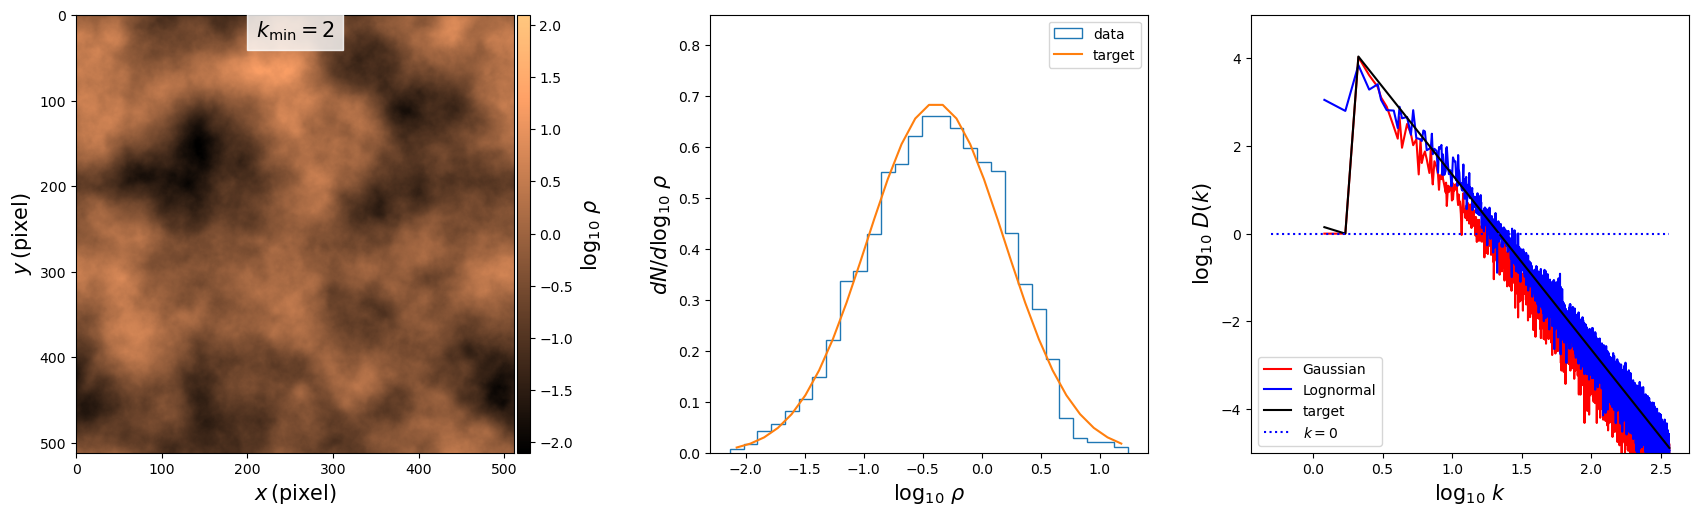

In [9]:
pyFC.plot_field_stats(fc, scaling='log', vmin=-2.1, vmax=2.1, cmap='copper')
plt.show()

In base to this stats, we need to extract the data from the first window of the previous plot, this plot uses the method plot_field_stats, so after reading the code from utils.py in the pyFC library code, this is how this data is extracted and plotted.

In [32]:
print('fc.cube.shape:', fc.cube.shape)
print('fc.ndim', fc.ndim)

fc.cube.shape: (512, 512, 1)
fc.ndim 2


In [33]:
fcs = pyFC.FCSlicer()
slice_ax2 = fcs.slice(fc, ax=2) #this method has ax=3, loc=0.5 by default
print('with ax=2, slice.shape', slice_ax2.shape)

#since this cube comes from a log normal dist, we have to apply a log10 so we can see
#the structure in the imagen, this took me time to solve but i finded the solution form paint_midplane_slice
slice_log = np.log10(slice_ax2)
print('after log10, min, max: ', np.nanmin(slice_log), np.nanmax(slice_log))

with ax=2, slice.shape (512, 512)
after log10, min, max:  -2.662771853289615 2.2305618452279363


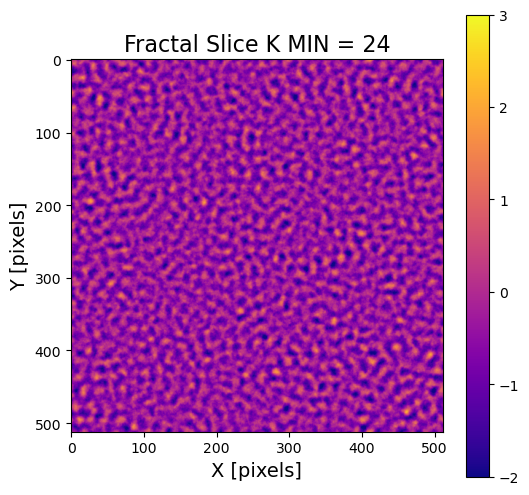

In [35]:
plt.figure(figsize=(6,6))
plt.imshow(slice_log, vmin=-2., vmax=3., cmap='plasma')
plt.title('Fractal Slice K MIN = 24', size=16)
plt.xlabel('X [pixels]', size=14)
plt.ylabel('Y [pixels]', size=14)
plt.colorbar()
plt.show()

Now that we have been able to replicate the extraction of the data from the cube, we can extrapolate this to a class to populate a dataset. 

For this, the idea is an HDF5 file which contains 6 data cubes, 1 data cube per $k_{min}$ detailed in the beginning. The HDF5 tensor should have a 512x512x1000x6 dimension.

In bits notation, each image should have an approximate weight of 1 MB, and the total tensor around 6 GB. This should be a good measurement for different types of training, even if we have to mount the whole dataset on RAM or use batch training.

**The DatasetGen class has been extracted to `dataset_generator.py` for reusability.**

In [ ]:
# DatasetGen class has been moved to dataset_generator.py
# Import it using: from dataset_generator import DatasetGen
# All configuration is loaded from dataset_config.ini

# Create generator instance with configuration file
generator = DatasetGen(config_file='dataset_config.ini')

DATASET GENERATOR CONFIGURATION
Config File: dataset_config.ini
Output File: fractal_dataset.h5
Batch Size: 10
Image Dimensions: 512 x 512 x 1
Images per K-value: 1000
K-values: [2, 4, 8, 16, 32, 64]
Distribution: mean=1.0, sigma=2.236, beta=-1.667
Compression: gzip (level 1)
Memory Monitoring: True
Logging: Enabled
Log File: dataset_generation.log


In [ ]:
def test_single_img(k_value=2):
    """Test before defining the whole dataset"""
    
    mem_before = generator.get_memory_usage()
    print(f'Initial RAM Usage: {mem_before:.2f} MB')
    
    # Generating a Test Image
    test_image = generator.single_image(k_value)
    
    mem_after = generator.get_memory_usage()
    print(f'Final RAM Usage: {mem_after:.2f} MB')
    print(f'Image Shape: {test_image.shape}, Min: {np.nanmin(test_image)}, Max: {np.nanmax(test_image)}')
    
    vmin = np.nanpercentile(test_image, 1)
    vmax = np.nanpercentile(test_image, 99)
    plt.figure(figsize=(6,6))
    plt.imshow(test_image, vmin=vmin, vmax=vmax, cmap='copper')
    plt.colorbar()
    plt.show()
    
    return test_image



def validation(filepath, generator):
    '''Validates the dataset structure and content'''
    
    if not os.path.exists(filepath):
        print(f'Filepath {filepath} does not exist.')
        return False
    try:
        with h5py.File(filepath, 'r') as f:
            print(f'Groups: {list(f.keys())}')
            
            total_images = 0
            for k in generator.k_values:
                group_name = f'k_{k}'
                
                if group_name in f:
                    group = f[group_name]
                    images = group['images']
                    labels = group['labels']
                    
                    print(f'k={k}: {images.shape}, labels: {labels.shape}')
                    total_images += images.shape[0]
                    
                    # Check some stats
                    sample_img = images[0]
                    print(f' Sample - min: {np.nanmin(sample_img):.3f}'
                          f' max: {np.nanmax(sample_img):.3f}'
                          f' finite count: {np.isfinite(sample_img).sum()}')
                else:
                    print(f'Group {group_name} missing!')
                    return False
                
            print(f'Total Images in Dataset: {total_images}')
            print('Dataset validation completed successfully.')
            return True
    except Exception as e:
        print(f'Error reading HDF5 file: {e}')
        return False



def preview(filepath, generator, samples_per_k=2):
    '''Previews random samples from the dataset'''
    
    fig, axes = plt.subplots(len(generator.k_values), samples_per_k, figsize=(
        4*samples_per_k, 4*len(generator.k_values)
    ))
    
    with h5py.File(filepath, 'r') as f:
        for k_idx, k in enumerate(generator.k_values):
            group = f[f'k_{k}']
            images = group['images']
            
            for sample_idx in range(samples_per_k):
                ax = axes[k_idx, sample_idx] if samples_per_k > 1 else axes[k_idx]
                
                # Random sample
                img_idx = np.random.randint(0, min(images.shape[0], 100))
                img = images[img_idx]
                
                # Display
                im = ax.imshow(img, cmap='copper', 
                            vmin=np.nanpercentile(img, 1), 
                            vmax=np.nanpercentile(img, 99))
                ax.set_title(f'k={k}, #{img_idx}')
                ax.axis('off')
                    
    plt.tight_layout()
    plt.show()

Initial RAM Usage: 218.53 MB
Final RAM Usage: 214.41 MB
Image Shape: (512, 512), Min: -2.382553507184195, Max: 1.4644295071059057


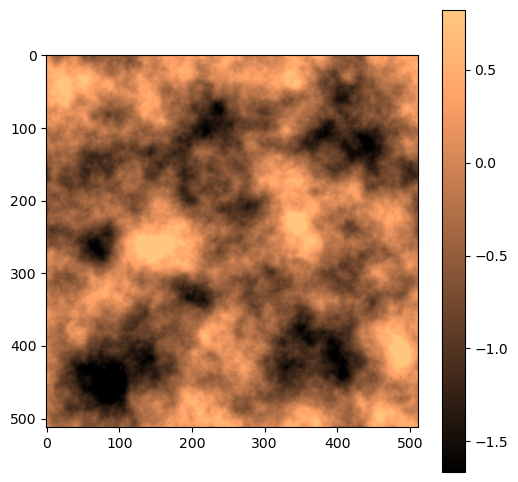

In [10]:
test_image = test_single_img(k_value=2)

In [11]:
generator.populate_dataset()

Initializing dataset population into fractal_dataset.h5
Initial RAM Usage: 214.47 MB

Processing k=2 (1/6)
Batch 1/100 | Images 0 to 9
Progress: 10/6000 | 2.5 img/s | ETA: 2427.7s | RAM: 215.25 MB
Batch 2/100 | Images 10 to 19
Progress: 20/6000 | 2.6 img/s | ETA: 2280.2s | RAM: 215.25 MB
Batch 3/100 | Images 20 to 29
Progress: 30/6000 | 2.7 img/s | ETA: 2235.0s | RAM: 233.13 MB
Batch 4/100 | Images 30 to 39
Progress: 40/6000 | 2.6 img/s | ETA: 2258.5s | RAM: 233.13 MB
Batch 5/100 | Images 40 to 49
Progress: 50/6000 | 2.6 img/s | ETA: 2268.4s | RAM: 233.13 MB
Batch 6/100 | Images 50 to 59
Progress: 60/6000 | 2.6 img/s | ETA: 2248.8s | RAM: 233.13 MB
Batch 7/100 | Images 60 to 69
Progress: 70/6000 | 2.7 img/s | ETA: 2202.0s | RAM: 215.25 MB
Batch 8/100 | Images 70 to 79
Progress: 80/6000 | 2.7 img/s | ETA: 2209.5s | RAM: 233.13 MB
Batch 9/100 | Images 80 to 89
Progress: 90/6000 | 2.7 img/s | ETA: 2200.1s | RAM: 233.13 MB
Batch 10/100 | Images 90 to 99
Progress: 100/6000 | 2.7 img/s | ETA

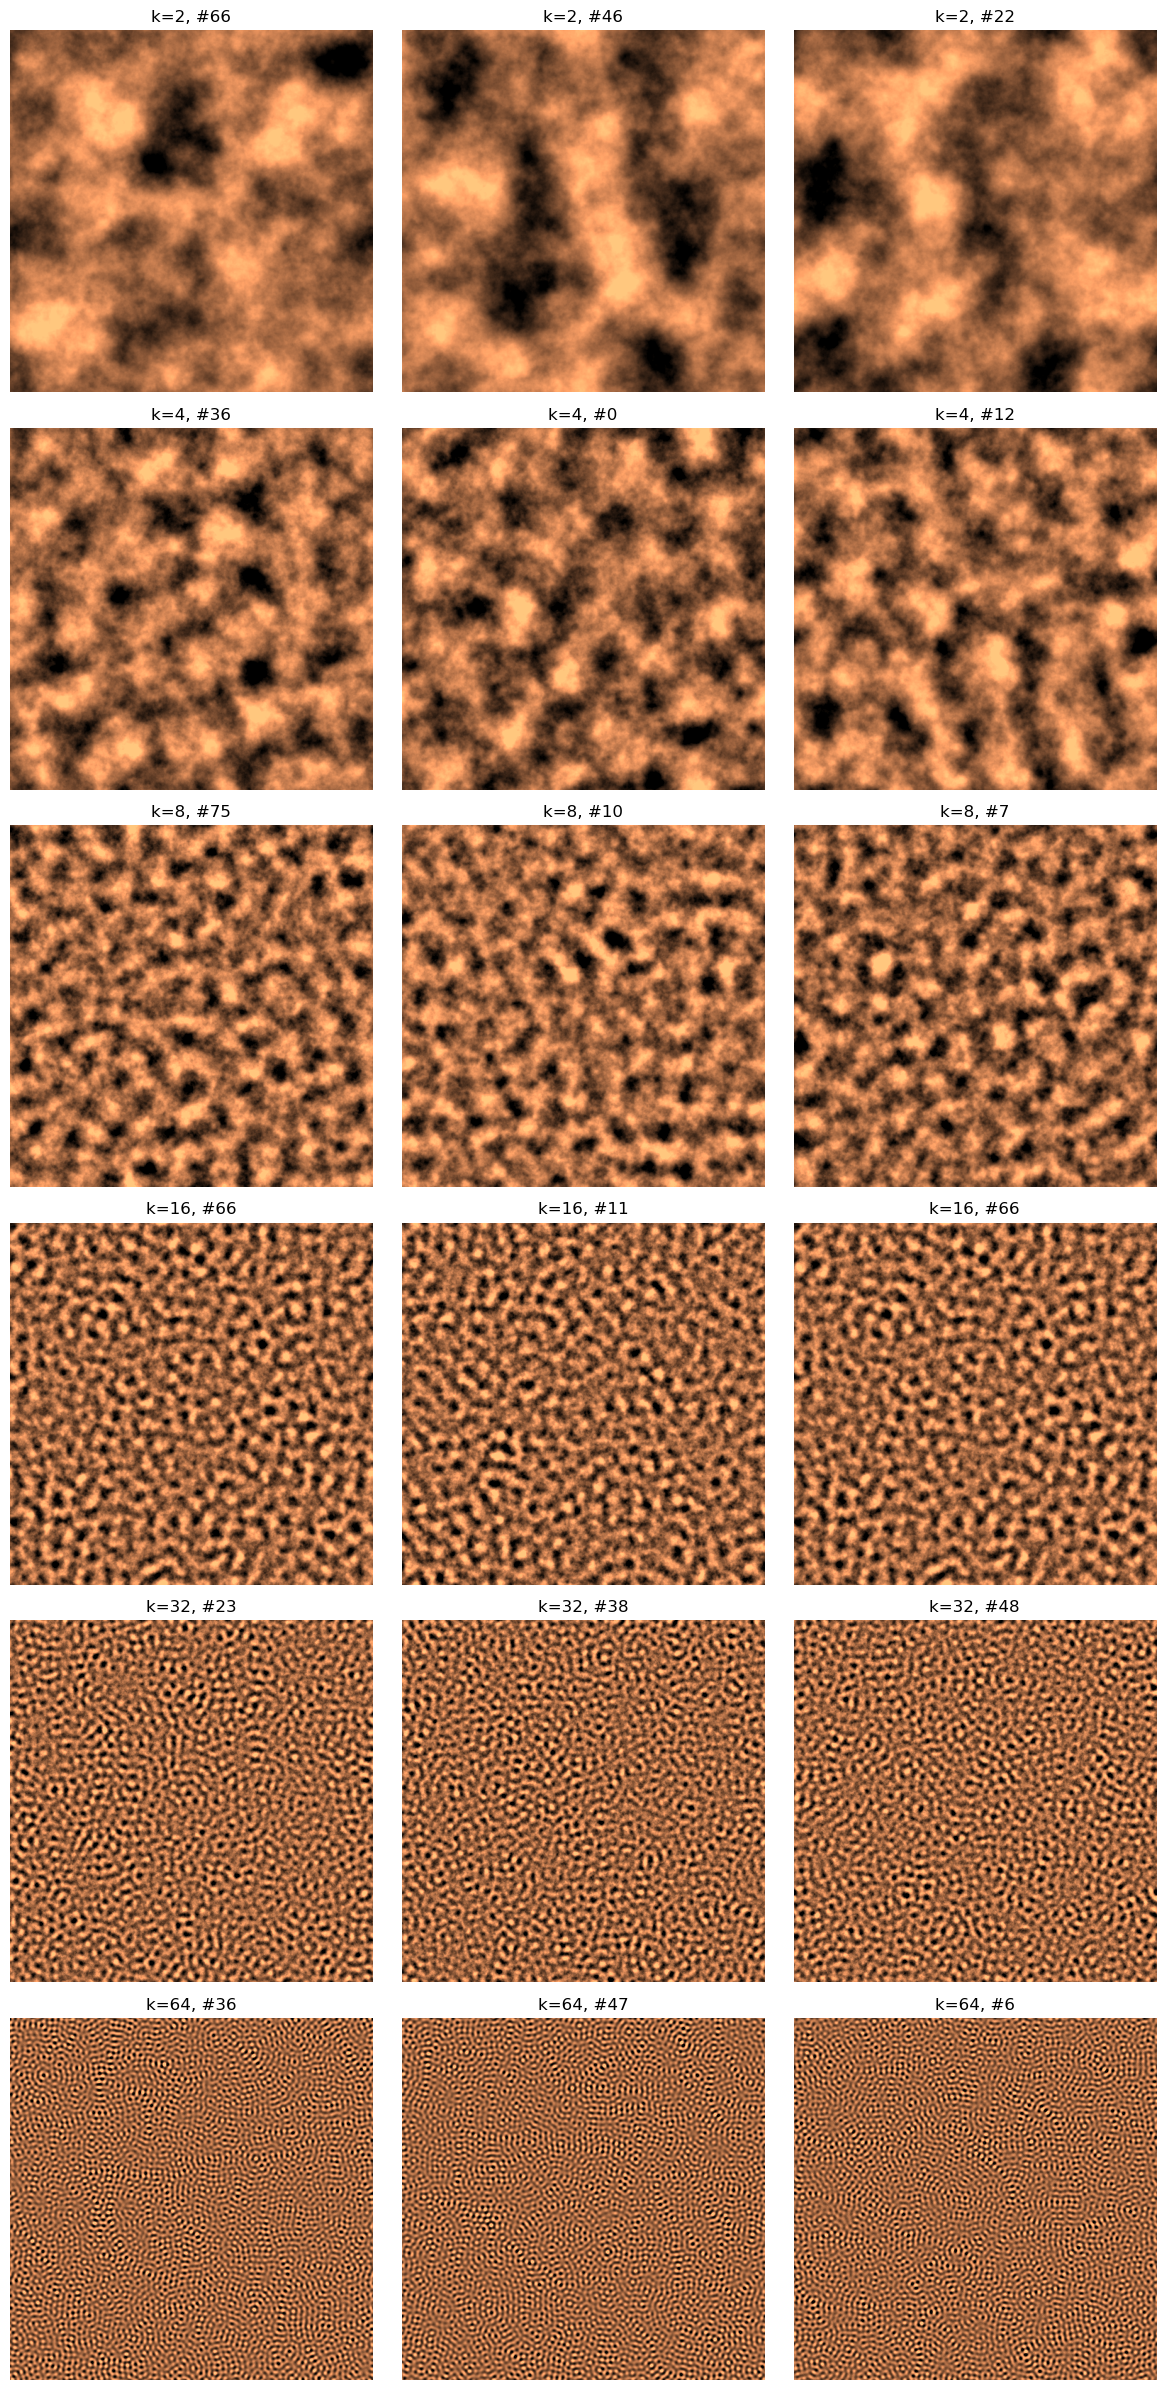

Groups: ['k_16', 'k_2', 'k_32', 'k_4', 'k_64', 'k_8']
k=2: (1000, 512, 512), labels: (1000,)
 Sample - min: -2.639 max: 1.330 finites count: 262144
k=4: (1000, 512, 512), labels: (1000,)
 Sample - min: -2.306 max: 1.590 finites count: 262144
k=8: (1000, 512, 512), labels: (1000,)
 Sample - min: -2.732 max: 1.748 finites count: 262144
k=16: (1000, 512, 512), labels: (1000,)
 Sample - min: -2.544 max: 1.877 finites count: 262144
k=32: (1000, 512, 512), labels: (1000,)
 Sample - min: -2.985 max: 2.068 finites count: 262144
k=64: (1000, 512, 512), labels: (1000,)
 Sample - min: -3.265 max: 2.372 finites count: 262144
Total Images in Dataset: 0
Dataset validation completed successfully.


True

In [ ]:
preview('fractal_dataset.h5', generator, samples_per_k=3)
validation('fractal_dataset.h5', generator)

k=2: únicos=1.00, correlación=0.14, coseno=0.33, diff_pixel=0.64
k=4: únicos=1.00, correlación=0.07, coseno=0.31, diff_pixel=0.65
k=8: únicos=1.00, correlación=0.03, coseno=0.32, diff_pixel=0.65
k=16: únicos=1.00, correlación=0.02, coseno=0.31, diff_pixel=0.66
k=32: únicos=1.00, correlación=0.01, coseno=0.31, diff_pixel=0.66
k=64: únicos=1.00, correlación=0.02, coseno=0.31, diff_pixel=0.66


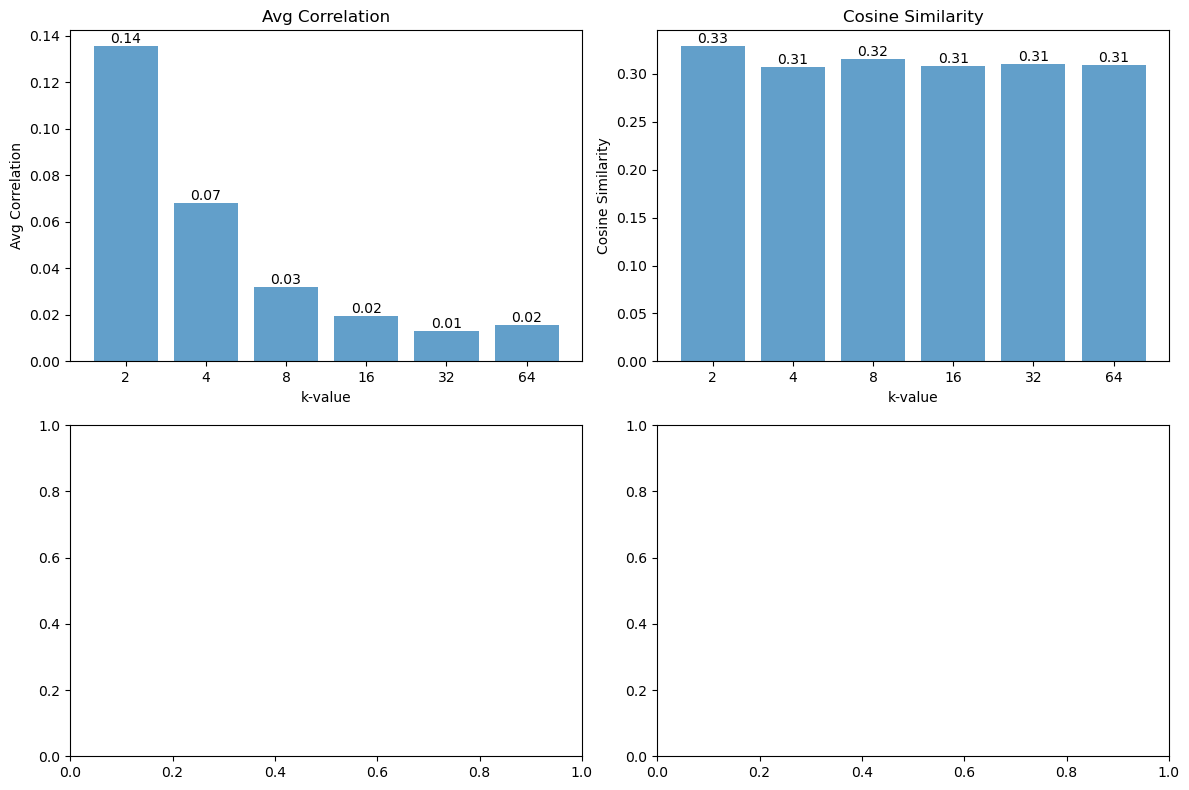

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import hashlib

def analyze_dataset_diversity(filepath, generator, n_samples=50):
    '''Analyzes dataset diversity using various metrics'''
    import scipy.stats

    diversity_results = {}
    with h5py.File(filepath, 'r') as f:
        for k in generator.k_values:
            images = f[f'k_{k}/images']
            total_images = images.shape[0]
            idx = np.random.choice(total_images, min(n_samples, total_images), replace=False)
            idx = np.sort(idx)
            sample_images = images[idx]

            hashes = {hashlib.md5(img.tobytes()).hexdigest() for img in sample_images}
            hash_uniqueness = len(hashes) / len(sample_images)

            correlations = [
                abs(np.corrcoef(sample_images[i].flatten(), sample_images[j].flatten())[0, 1])
                for i in range(min(20, len(sample_images)))
                for j in range(i+1, min(20, len(sample_images)))
            ]
            avg_correlation = np.mean(correlations) if correlations else 0

            flat_images = sample_images.reshape(len(sample_images), -1)
            cos_sim = cosine_similarity(flat_images[:20])
            mask = np.triu(np.ones_like(cos_sim, dtype=bool), k=1)
            avg_cosine_sim = np.mean(np.abs(cos_sim[mask]))

            pixel_diffs = [
                np.mean(np.abs(sample_images[i] - sample_images[j]))
                for i in range(min(10, len(sample_images)))
                for j in range(i+1, min(10, len(sample_images)))
            ]
            avg_pixel_diff = np.mean(pixel_diffs) if pixel_diffs else 0

            diversity_results[k] = {
                'hash_uniqueness': hash_uniqueness,
                'avg_correlation': avg_correlation,
                'avg_cosine_similarity': avg_cosine_sim,
                'avg_pixel_difference': avg_pixel_diff,
                'n_samples': len(sample_images)
            }
            print(f"k={k}: unique={hash_uniqueness:.2f}, correlation={avg_correlation:.2f}, cosine={avg_cosine_sim:.2f}, pixel_diff={avg_pixel_diff:.2f}")
    return diversity_results

def plot_diversity_metrics(diversity_results):
    k_values = list(diversity_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    metrics = [
        # ('hash_uniqueness', 'Hash Uniqueness'),
        ('avg_correlation', 'Avg Correlation'),
        ('avg_cosine_similarity', 'Cosine Similarity'),
        # ('avg_pixel_difference', 'Pixel Difference')
    ]
    for i, (metric, title) in enumerate(metrics):
        values = [diversity_results[k][metric] for k in k_values]
        axes[i].bar(range(len(k_values)), values, alpha=0.7)
        axes[i].set_title(title)
        axes[i].set_xlabel('k-value')
        axes[i].set_ylabel(title)
        axes[i].set_xticks(range(len(k_values)))
        axes[i].set_xticklabels(k_values)
        for j, v in enumerate(values):
            axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# Example usage:
diversity_results = analyze_dataset_diversity('fractal_dataset.h5', generator, n_samples=100)
plot_diversity_metrics(diversity_results)

In [ ]:
import datetime

def analyze_hdf5_file(filepath='fractal_dataset.h5'):
    '''Comprehensive analysis of HDF5 dataset file'''

    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return

    file_size_bytes = os.path.getsize(filepath)
    file_size_mb = file_size_bytes / (1024**2)
    file_size_gb = file_size_bytes / (1024**3)
    file_stat = os.stat(filepath)
    creation_time = datetime.datetime.fromtimestamp(file_stat.st_ctime)
    modification_time = datetime.datetime.fromtimestamp(file_stat.st_mtime)

    print("HDF5 DATASET ANALYSIS")
    print("=" * 60)
    print(f"Path: {filepath}")
    print(f"Size: {file_size_mb:.2f} MB ({file_size_gb:.3f} GB)")
    print(f"Exact size: {file_size_bytes:,} bytes")
    print(f"Created: {creation_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Modified: {modification_time.strftime('%Y-%m-%d %H:%M:%S')}")

    with h5py.File(filepath, 'r') as f:
        print("\nHDF5 STRUCTURE:")
        print(f"Number of root groups: {len(f.keys())}")
        print(f"Groups: {list(f.keys())}")

        total_datasets = 0
        total_images = 0
        total_memory_usage = 0

        print("\nANALYSIS BY K-VALUE:")
        print("-" * 50)
        for k_name in sorted(f.keys()):
            k_group = f[k_name]
            k_value = k_group.attrs.get('k_value', 'N/A')
            print(f"\nGroup: {k_name} (k={k_value})")
            datasets = list(k_group.keys())
            print(f"   Datasets: {datasets}")

            if 'images' in k_group:
                images_ds = k_group['images']
                shape = images_ds.shape
                dtype = images_ds.dtype
                size_bytes = images_ds.size * images_ds.dtype.itemsize
                size_mb = size_bytes / (1024**2)
                total_images += shape[0]
                total_memory_usage += size_bytes
                total_datasets += 1
                print(f"   Images:")
                print(f"      Shape: {shape}")
                print(f"      Dtype: {dtype}")
                print(f"      Size: {size_mb:.2f} MB")
                print(f"      Compression: {images_ds.compression}")
                print(f"      Chunks: {images_ds.chunks}")

                sample_indices = np.random.choice(shape[0], min(10, shape[0]), replace=False)
                sample_images = images_ds[np.sort(sample_indices)]
                min_val = np.min(sample_images)
                max_val = np.max(sample_images)
                mean_val = np.mean(sample_images)
                std_val = np.std(sample_images)
                print(f"      Statistics (sample of {len(sample_images)}):")
                print(f"         Min: {min_val:.4f}")
                print(f"         Max: {max_val:.4f}")
                print(f"         Mean: {mean_val:.4f}")
                print(f"         Std: {std_val:.4f}")

            if 'labels' in k_group:
                labels_ds = k_group['labels']
                unique_labels = np.unique(labels_ds[:])
                print(f"   Labels:")
                print(f"      Shape: {labels_ds.shape}")
                print(f"      Dtype: {labels_ds.dtype}")
                print(f"      Unique values: {unique_labels}")

            print(f"   Metadata:")
            for attr_name, attr_value in k_group.attrs.items():
                print(f"      {attr_name}: {attr_value}")

        print("\nGENERAL SUMMARY:")
        print("-" * 30)
        print(f"   Total images: {total_images:,}")
        print(f"   Total datasets: {total_datasets}")
        print(f"   Total data memory: {total_memory_usage/(1024**2):.2f} MB")
        print(f"   Average per image: {(total_memory_usage/total_images)/1024:.2f} KB")
        print(f"   Compression ratio: {(total_memory_usage/file_size_bytes)*100:.1f}%")

        print("\nINTEGRITY VERIFICATION:")
        print("-" * 35)
        integrity_checks = {
            'Expected groups': len(f.keys()) == 6,
            'Correct total images': total_images == 6000,
            'Images per k-value': True,
            'Metadata present': True,
            'Compression applied': True
        }
        for k_name in f.keys():
            if 'images' in f[k_name]:
                if f[k_name]['images'].shape[0] != 1000:
                    integrity_checks['Images per k-value'] = False
                    break
        required_attrs = ['k_value', 'method', 'mean', 'sigma', 'beta', 'creation_date']
        for k_name in f.keys():
            for attr in required_attrs:
                if attr not in f[k_name].attrs:
                    integrity_checks['Metadata present'] = False
                    break
            if not integrity_checks['Metadata present']:
                break
        for k_name in f.keys():
            if 'images' in f[k_name]:
                if f[k_name]['images'].compression is None:
                    integrity_checks['Compression applied'] = False
                    break
        for check, result in integrity_checks.items():
            print(f"   {check}: {'OK' if result else 'FAILED'}")

        print("\nML COMPATIBILITY:")
        print("-" * 25)
        sample_shape = f['k_2']['images'].shape
        channels_last = sample_shape[1:] == (512, 512)
        print(f"   Shape per image: {sample_shape[1:]}")
        print(f"   Format: {'Channels-last (H,W)' if channels_last else 'Custom'}")
        print(f"   Dtype: {f['k_2']['images'].dtype} (compatible with float32)")
        print(f"   Labels: Categorical (k-values)")
        print(f"   Balanced: {'Yes' if total_images/6 == 1000 else 'No'}")

        single_image_mb = (512 * 512 * 4) / (1024**2)
        batch_32_mb = single_image_mb * 32
        full_dataset_mb = single_image_mb * total_images
        print(f"\nML MEMORY ESTIMATES:")
        print(f"   Single image: {single_image_mb:.2f} MB")
        print(f"   Batch of 32: {batch_32_mb:.2f} MB")
        print(f"   Complete dataset: {full_dataset_mb:.2f} MB ({full_dataset_mb/1024:.2f} GB)")

# Run analysis
analyze_hdf5_file('fractal_dataset.h5')

ANÁLISIS DEL DATASET HDF5
Ruta: fractal_dataset.h5
Tamaño: 5529.21 MB (5.400 GB)
Tamaño exacto: 5,797,800,632 bytes
Creado: 2025-10-04 17:27:24
Modificado: 2025-10-04 17:27:24

ESTRUCTURA HDF5:
Número de grupos raíz: 6
Grupos: ['k_16', 'k_2', 'k_32', 'k_4', 'k_64', 'k_8']

ANÁLISIS POR K-VALUE:
--------------------------------------------------

Grupo: k_16 (k=16)
   Datasets: ['images', 'labels']
   Imágenes:
      Shape: (1000, 512, 512)
      Dtype: float32
      Tamaño: 1000.00 MB
      Compresión: gzip
      Chunks: (1, 512, 512)
      Estadísticas (muestra de 10):
         Min: -3.1186
         Max: 2.1322
         Mean: -0.3894
         Std: 0.5842
   Labels:
      Shape: (1000,)
      Dtype: int32
      Valores únicos: [16]
   Metadatos:
      batch_size: 10
      beta: -1.6666666666666667
      config_file: dataset_config.ini
      creation_date: 2025-10-04T16:40:04.841667
      image_dimensions: [512 512   1]
      k_value: 16
      mean: 1.0
      method: lognormal
      sig

## Generate HDF5 with Intermediate K Values Using the `DatasetGen` Class

Next, we create a new instance of `DatasetGen` but override some parameters to generate a `fractal_dataset_intermediate.h5` file with intermediate K values and 200 images per K. This reuses all the code and validations already defined in the notebook.

In [ ]:
# Generate a test HDF5 with intermediate k values (uses DatasetGen class and its validations)
# Configuration: 200 images per k and list of intermediate k values for comparison
intermediate_output = 'fractal_dataset_intermediate.h5'
intermediate_k_values = [3, 6, 12, 24, 48]
intermediate_num_images = 200

# Create a new generator reusing the config file but overriding parameters
gen_inter = DatasetGen(config_file='dataset_config.ini',
                       output_file=intermediate_output,
                       k_values=intermediate_k_values,
                       num_images=intermediate_num_images)

# Run generation (this step may take time; images are written in batches according to the class)
print(f"Generating {intermediate_num_images} images per k into {intermediate_output} for k={intermediate_k_values}")
gen_inter.populate_dataset()
print('Done: intermediate dataset generated')

DATASET GENERATOR CONFIGURATION
Config File: dataset_config.ini
Output File: fractal_dataset_intermediate.h5
Batch Size: 10
Image Dimensions: 512 x 512 x 1
Images per K-value: 200
K-values: [3, 6, 12, 24, 48]
Distribution: mean=1.0, sigma=2.236, beta=-1.667
Compression: gzip (level 1)
Memory Monitoring: True
Logging: Enabled
Log File: dataset_generation.log
Generating 200 images per k into fractal_dataset_intermediate.h5 for k=[3, 6, 12, 24, 48]
Initializing dataset population into fractal_dataset_intermediate.h5
Initial RAM Usage: 194.78 MB

Processing k=3 (1/5)
Batch 1/20 | Images 0 to 9
Progress: 10/1000 | 2.5 img/s | ETA: 401.2s | RAM: 201.48 MB
Batch 2/20 | Images 10 to 19
Progress: 20/1000 | 2.3 img/s | ETA: 417.6s | RAM: 195.48 MB
Batch 3/20 | Images 20 to 29
Progress: 30/1000 | 2.4 img/s | ETA: 408.2s | RAM: 195.48 MB
Batch 4/20 | Images 30 to 39
Progress: 40/1000 | 2.5 img/s | ETA: 390.9s | RAM: 195.48 MB
Batch 5/20 | Images 40 to 49
Progress: 50/1000 | 2.5 img/s | ETA: 381.9s